# Identitas Diri
Nama : Muhammad Fattahul Alim

NIM : 244107020018

Kelas : TI - 3G

Absen : 15


In [1]:
#Import Library
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
N_SAMPLE = 10000   # jumlah data yang sama untuk semua notebook (K-Means dan DBSCAN)
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050' | Random state: 42 | N_SAMPLE: 10000


In [2]:
# Load data
DATASET_PATH = '/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_binary_5050split_health_indicators_BRFSS2015.csv'
df_raw = pd.read_csv(DATASET_PATH)
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 70692 baris x 22 kolom


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
# Cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):")
print(df_raw['Diabetes_binary'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 1635

Sebaran kelas Diabetes_binary (0 = tidak diabetes, 1 = diabetes):
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [4]:
# Preprocessing

# Menentukan fitur dan target
LABEL_COL = 'Diabetes_binary'
DROP_COLS = ['Income', 'Education', 'AnyHealthcare', 'NoDocbcCost', 'CholCheck', 'HvyAlcoholConsump']

df = df_raw.drop(columns=DROP_COLS)
print(f"Setelah buang kolom        : {df.shape[1]} kolom (termasuk label)")

n_sebelum_dup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")
print(f"Sebaran kelas              : {df[LABEL_COL].value_counts().sort_index().to_dict()}")

n_per_kelas = N_SAMPLE // 2
assert df[LABEL_COL].value_counts().min() >= n_per_kelas, "Salah satu kelas kurang dari jumlah sampel per kelas"
df_sample_all = (df.groupby(LABEL_COL).sample(n=n_per_kelas, random_state=RANDOM_STATE)
                   .sample(frac=1, random_state=RANDOM_STATE)
                   .reset_index(drop=True))

y_sample = df_sample_all[LABEL_COL].copy()   # label hanya untuk pembanding, tidak dipakai klastering
df_features = df_sample_all.drop(columns=[LABEL_COL]).astype(float)
print(f"Data klastering            : {df_features.shape[0]} baris x {df_features.shape[1]} fitur")
print(f"Sebaran label sampel       : {y_sample.value_counts().sort_index().to_dict()}")
print(f"Daftar fitur               : {list(df_features.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Cek mean 0 dan std 1       : {X_scaled.mean():.4f} / {X_scaled.std():.4f}")
df_features.head()

Setelah buang kolom        : 16 kolom (termasuk label)
Setelah hapus duplikat     : 63197 baris (terbuang 7495)
Sebaran kelas              : {0.0: 29885, 1.0: 33312}
Data klastering            : 10000 baris x 15 fitur
Sebaran label sampel       : {0.0: 5000, 1.0: 5000}
Daftar fitur               : ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age']
Cek mean 0 dan std 1       : -0.0000 / 1.0000


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age
0,1.0,1.0,26.0,1.0,0.0,1.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,1.0,11.0
1,1.0,0.0,30.0,1.0,0.0,0.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,1.0,11.0
2,1.0,0.0,35.0,1.0,0.0,0.0,0.0,1.0,1.0,4.0,5.0,20.0,1.0,0.0,11.0
3,1.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0
4,0.0,0.0,24.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0


In [5]:
# Class Kmeans
class KMeansManhattan:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0   # SAE (Sum of Absolute Errors)
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(X, centroids, metric='manhattan')

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape
        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]
        for _ in range(1, self.n_clusters):
            dists = self._compute_distance(X, np.array(centroids))
            sq_dists = np.min(dists, axis=1) ** 2
            sum_sq = np.sum(sq_dists)
            probs = np.ones(n_samples) / n_samples if sum_sq == 0 else sq_dists / sum_sq
            centroids.append(X[rng.choice(n_samples, p=probs)])
        return np.array(centroids)

    def fit(self, X):
        start_time = time.perf_counter()
        self.centroids = self._init_centroids(X)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1
            dists = self._compute_distance(X, self.centroids)
            labels = np.argmin(dists, axis=1)

            new_centroids = np.zeros_like(self.centroids)
            rng = np.random.RandomState(self.random_state)
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) == 0:
                    new_centroids[k] = X[rng.randint(len(X))]
                else:
                    new_centroids[k] = np.median(cluster_pts, axis=0)   # update: median per fitur (K-Medians)

            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            self.labels_ = labels
            if shift < self.tol:
                break

        final_dists = self._compute_distance(X, self.centroids)
        assigned = final_dists[np.arange(len(X)), self.labels_]
        self.inertia_ = float(np.sum(assigned))   # SAE
        self.execution_time_ = float(time.perf_counter() - start_time)
        return self

print("[INFO] Kelas KMeansManhattan berhasil diinisialisasi.")

[INFO] Kelas KMeansManhattan berhasil diinisialisasi.


  k = 1  | SAE = 105,069.32 | iterasi = 2
  k = 2  | SAE = 89,757.91 | iterasi = 5
  k = 3  | SAE = 78,676.92 | iterasi = 4
  k = 4  | SAE = 76,309.44 | iterasi = 10
  k = 5  | SAE = 74,419.79 | iterasi = 10
  k = 6  | SAE = 73,576.40 | iterasi = 7
  k = 7  | SAE = 72,322.81 | iterasi = 7
  k = 8  | SAE = 70,296.60 | iterasi = 8
  k = 9  | SAE = 68,790.73 | iterasi = 6
  k = 10 | SAE = 67,928.79 | iterasi = 7
[ELBOW] Elbow metrik ini: k = 3 | k dipakai (acuan Euclidean): k = 4
[SIMPAN] Grafik Elbow disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/elbow_manhattan.png'


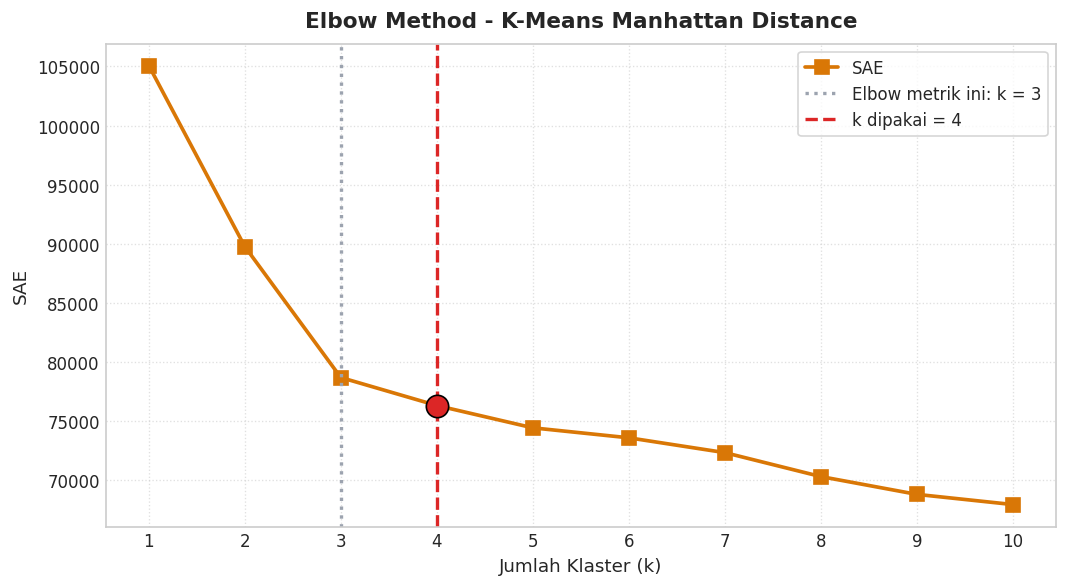

In [6]:
# Elbow Manhattan
k_range = list(range(1, 11))
obj_list = []

for k in k_range:
    km = KMeansManhattan(n_clusters=k, max_iter=200, random_state=RANDOM_STATE).fit(X_scaled)
    obj_list.append(km.inertia_)
    print(f"  k = {k:<2} | SAE = {km.inertia_:,.2f} | iterasi = {km.n_iter_}")

def find_elbow_point(k_vals, vals):
    # kedua sumbu dinormalisasi 0-1 agar deteksi siku sebanding antar metrik
    x = (np.array(k_vals, dtype=float) - k_vals[0]) / (k_vals[-1] - k_vals[0])
    y = (np.array(vals, dtype=float) - min(vals)) / (max(vals) - min(vals))
    p1 = np.array([x[0], y[0]])
    line_unit = np.array([x[-1], y[-1]]) - p1
    line_unit = line_unit / np.linalg.norm(line_unit)
    pts = np.column_stack([x, y]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    return k_vals[int(np.argmax(np.linalg.norm(pts - proj, axis=1)))]

elbow_k = find_elbow_point(k_range, obj_list)
# k disamakan dengan hasil elbow Euclidean (jalankan notebook Euclidean terlebih dahulu)
ref_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_euclidean.xlsx")
if not os.path.exists(ref_path):
    raise FileNotFoundError("Jalankan notebook K-Means Euclidean lebih dulu: k acuan dibaca dari hasilnya.")
K_FINAL = int(pd.read_excel(ref_path, sheet_name='Ringkasan_Evaluasi')['Optimal k'].iloc[0])
print(f"[ELBOW] Elbow metrik ini: k = {elbow_k} | k dipakai (acuan Euclidean): k = {K_FINAL}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, obj_list, marker='s', markersize=8, linewidth=2.2, color='#D97706', label='SAE')
plt.axvline(x=elbow_k, color='#9CA3AF', linestyle=':', linewidth=2, label=f'Elbow metrik ini: k = {elbow_k}')
plt.axvline(x=K_FINAL, color='#DC2626', linestyle='--', linewidth=2, label=f'k dipakai = {K_FINAL}')
plt.scatter([K_FINAL], [obj_list[K_FINAL - 1]], color='#DC2626', s=180, zorder=5, edgecolor='black')
plt.title('Elbow Method - K-Means Manhattan Distance', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Jumlah Klaster (k)', fontsize=11)
plt.ylabel('SAE', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, "elbow_manhattan.png")
plt.savefig(elbow_path, dpi=300)
print(f"[SIMPAN] Grafik Elbow disimpan ke: '{elbow_path}'")
plt.show()

# Nilai kurva elbow disimpan untuk grafik gabungan di notebook perbandingan
pd.DataFrame({'k': k_range, 'objective': obj_list}).to_csv(os.path.join(OUTPUT_DIR, "elbow_values_manhattan.csv"), index=False)

In [7]:
# klastering final, evaluasi, dan simpan hasil
model_kmeans = KMeansManhattan(n_clusters=K_FINAL, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(X_scaled)
labels = model_kmeans.labels_

sil_score = float(silhouette_score(X_scaled, labels, metric='manhattan'))
db_score = float(davies_bouldin_score(X_scaled, labels))
ch_score = float(calinski_harabasz_score(X_scaled, labels))

eval_df = pd.DataFrame([{
    'Distance Metric': 'Manhattan Distance (L1)',
    'Optimal k': K_FINAL,
    'k Elbow (metrik ini)': elbow_k,
    'Jumlah Data': X_scaled.shape[0],
    'Jumlah Fitur': X_scaled.shape[1],
    'Silhouette Score (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_kmeans.execution_time_, 5),
    'Iterations (↓)': model_kmeans.n_iter_,
    'Objective Value (SAE) (↓)': round(model_kmeans.inertia_, 2)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI K-MEANS MANHATTAN")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

df_clustered = df_features.copy()
df_clustered['Diabetes_binary'] = y_sample.values
df_clustered['Cluster_Manhattan'] = labels

profil = df_clustered.groupby('Cluster_Manhattan').mean().round(3)
profil.insert(0, 'Jumlah Data', df_clustered['Cluster_Manhattan'].value_counts().sort_index())
profil['% Diabetes'] = (df_clustered.groupby('Cluster_Manhattan')['Diabetes_binary'].apply(lambda s: (s == 1).mean() * 100)).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_kmeans_manhattan.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_kmeans_manhattan.csv")
df_clustered.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")




TABEL EVALUASI K-MEANS MANHATTAN
Distance Metric              Manhattan Distance (L1)
Optimal k                                          4
k Elbow (metrik ini)                               3
Jumlah Data                                    10000
Jumlah Fitur                                      15
Silhouette Score (↑)                          0.1428
Davies–Bouldin Index (↓)                      2.7753
Calinski–Harabasz Index (↑)                   818.45
Execution Time (s) (↓)                       0.05988
Iterations (↓)                                    10
Objective Value (SAE) (↓)                   76309.44
[SIMPAN] Evaluasi & profil klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/evaluasi_kmeans_manhattan.xlsx'
[SIMPAN] Data terklaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/data_terklaster_kmeans_manhattan.csv'


In [8]:
# Profil Tiap Klaster
profil

,Jumlah Data,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Diabetes_binary,% Diabetes
Cluster_Manhattan,,,,,,,,,,,,,,,,,,
0,3017,0.744,0.789,30.268,0.657,0.056,0.102,0.740,0.257,0.711,2.825,3.065,3.855,0.150,0.727,8.832,0.558,55.75
1,3878,0.244,0.260,28.447,0.257,0.021,0.015,0.810,0.735,0.822,2.340,3.062,2.469,0.079,0.278,7.498,0.289,28.86
2,2080,0.812,0.756,33.184,0.615,0.141,0.237,0.266,0.654,0.728,3.971,8.649,18.074,0.841,0.241,9.489,0.738,73.85
3,1025,0.814,0.368,29.655,0.708,0.123,0.683,0.795,0.875,0.823,3.101,2.691,5.013,0.238,0.770,10.161,0.647,64.68


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/cluster_manhattan.png'


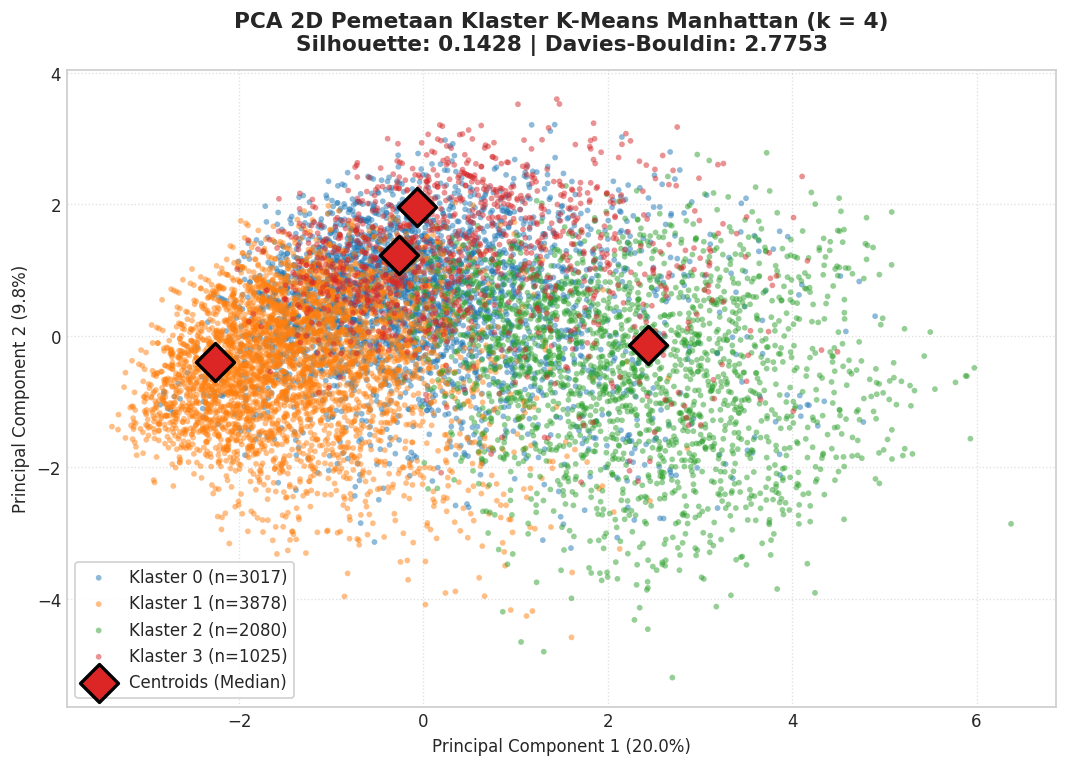

In [9]:
# Visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(model_kmeans.centroids)

plt.figure(figsize=(9, 6.5))
palette = sns.color_palette("tab10", K_FINAL)

for k in range(K_FINAL):
    mask = (labels == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[k], label=f'Klaster {k} (n={np.sum(mask)})',
                alpha=0.5, s=12, edgecolors='none')

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='D', s=260, c='#DC2626',
            edgecolor='black', linewidth=2, label='Centroids (Median)', zorder=10)

plt.title(f'PCA 2D Pemetaan Klaster K-Means Manhattan (k = {K_FINAL})\n'
          f'Silhouette: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=13, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_manhattan.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()

In [10]:
# Fitur paling berpengaruh
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))

Fitur paling berpengaruh di PC1:
GenHlth                 0.440
DiffWalk                0.406
PhysHlth                0.395
HighBP                  0.301
HeartDiseaseorAttack    0.262
PhysActivity            0.243
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age                     0.525
MentHlth                0.459
HighBP                  0.328
HeartDiseaseorAttack    0.298
PhysHlth                0.276
HighChol                0.265
Name: PC2, dtype: float64


In [11]:
# tabel sensitivitas k (k-1, k, k+1 dan k elbow metrik ini)
SIL_SAMPLE = None   # data penuh (Kaggle): isi 10000 agar Silhouette tidak terlalu lama
SENS_STEP = 1       # k yang diuji: K_FINAL - 1, K_FINAL, K_FINAL + 1

k_uji = sorted({k for k in [K_FINAL - SENS_STEP, K_FINAL, K_FINAL + SENS_STEP, int(elbow_k)] if 2 <= k <= max(k_range)})
rows = []

for k in k_uji:
    m = KMeansManhattan(n_clusters=k, max_iter=300, tol=1e-4, random_state=RANDOM_STATE).fit(X_scaled)
    lab = m.labels_
    ukuran = np.bincount(lab, minlength=k) / len(lab) * 100
    catatan = []
    if k == K_FINAL:
        catatan.append('k dipakai (acuan Euclidean)')
    if k == int(elbow_k):
        catatan.append('k elbow metrik ini')
    rows.append({
        'Distance Metric': 'Manhattan',
        'k': k,
        'Keterangan': ' + '.join(catatan),
        'Silhouette (↑)': round(silhouette_score(X_scaled, lab, metric='manhattan', sample_size=SIL_SAMPLE, random_state=RANDOM_STATE), 4),
        'Davies–Bouldin (↓)': round(davies_bouldin_score(X_scaled, lab), 4),
        'Calinski–Harabasz (↑)': round(calinski_harabasz_score(X_scaled, lab), 2),
        'Klaster Terkecil (%)': round(ukuran.min(), 2),
        'Klaster Terbesar (%)': round(ukuran.max(), 2),
        'Iterasi (↓)': m.n_iter_
    })
    print(f"  k = {k} selesai")

sens_df = pd.DataFrame(rows)
print("\n" + "=" * 110)
print("TABEL SENSITIVITAS K - K-MEANS MANHATTAN")
print("=" * 110)
print(sens_df.to_string(index=False))

sens_path = os.path.join(OUTPUT_DIR, "sensitivitas_k_manhattan.csv")
sens_df.to_csv(sens_path, index=False)
print(f"[SIMPAN] Tabel sensitivitas disimpan ke: '{sens_path}'")

  k = 3 selesai
  k = 4 selesai
  k = 5 selesai

TABEL SENSITIVITAS K - K-MEANS MANHATTAN
Distance Metric  k                  Keterangan  Silhouette (↑)  Davies–Bouldin (↓)  Calinski–Harabasz (↑)  Klaster Terkecil (%)  Klaster Terbesar (%)  Iterasi (↓)
      Manhattan  3          k elbow metrik ini          0.1491              2.8348                1041.18                 22.35                 41.79            4
      Manhattan  4 k dipakai (acuan Euclidean)          0.1428              2.7753                 818.45                 10.25                 38.78           10
      Manhattan  5                                      0.1230              3.2066                 721.19                  6.17                 33.99           10
[SIMPAN] Tabel sensitivitas disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/sensitivitas_k_manhattan.csv'
